# NE-EpiGuard: Waterborne Disease Outbreak Prediction — Northeast India
## Exploratory Data Analysis (EDA)

---

## 1. Problem Statement

### What is a Waterborne Disease Outbreak?
Waterborne diseases are illnesses caused by pathogenic microorganisms transmitted through contaminated water. In Northeast India, a region characterized by extreme monsoon patterns, high flooding frequency, and significant variation in sanitation infrastructure across its 8 states, waterborne diseases like Cholera, Typhoid, Dysentery, Hepatitis A/E, Leptospirosis, and Giardiasis remain a persistent public health challenge.

### Why Northeast India?
The Northeast region contributes disproportionately to India's waterborne disease burden:
- **Extreme monsoon seasonality** — some districts receive 1000mm+ rainfall in June–August alone
- **High flooding incidence** — especially in Assam, Meghalaya, and Tripura floodplains
- **Sanitation gaps** — open defecation rates and untreated water sources remain elevated in remote districts
- **Geographic remoteness** — many hill districts in Arunachal Pr|adesh, Nagaland, and Mizoram have limited healthcare access, making early prediction critical

### Our Goal
Using patient-level data capturing demographics, water quality parameters, environmental conditions, sanitation indicators, and clinical symptoms across all 8 Northeast Indian states, we aim to:
1. **Understand** the distribution and drivers of each disease class
2. **Identify** which water quality parameters, climate factors, and sanitation indicators most strongly predict disease type
3. **Prepare** a clean, feature-engineered dataset for multi-class disease classification
4. **Power** an AI advisory system that provides health guidance and specialist recommendations

### Disease Classes
| Disease | Transmission Route | Key Risk Factors |
|---|---|---|
| Cholera | Fecal-oral via water | High fecal coliform, flooding, untreated water |
| Typhoid | Contaminated water/food | Poor sanitation, high TDS, open defecation |
| Dysentery | Contaminated water | High turbidity, untreated sources |
| Hepatitis A | Fecal-oral | Poor handwashing, low WQI |
| Hepatitis E | Contaminated water | Flooding, low dissolved oxygen |
| Leptospirosis | Soil/water contact | Flooding, animal contact, monsoon |
| Giardiasis | Contaminated water | Low WQI, surface water sources |
| No Disease | — | Good water quality, sanitation |

---

## 2. Basic Data Checks

In [14]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

%matplotlib inline

# Set background graph style
plt.style.use('dark_background')

# import warnings to ignore the warnings
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
data = pd.read_csv(r'D:\NE-EpiGuard\Notebooks\Data\northeast_waterborne.csv')
# 1. Check Shape
print('Data Shape:', data.shape)

# 2. View first few rows
display(data.head())

# 3. Info to see column types and non-null counts
print('\nData Info:')
data.info()

# 4. Summary statistics for numeric columns
print('\nNumeric Summary:')
display(data.describe())

# 5. Unique values per column
print('\nUnique Values Count:')
print(data.nunique())

#6 Checking duplicate rows
print('\n=== DUPLICATE ROWS ===')
print(f'Duplicates: {data.duplicated().sum()}')

Data Shape: (405074, 39)


,state,district,latitude,longitude,population_density,age,gender,water_source,water_treatment,water_quality_index,ph,turbidity_ntu,dissolved_oxygen_mg_l,bod_mg_l,fecal_coliform_per_100ml,total_coliform_per_100ml,tds_mg_l,nitrate_mg_l,fluoride_mg_l,arsenic_ug_l,open_defecation_rate,toilet_access,sewage_treatment_pct,handwashing_practice,month,season,avg_temperature_c,avg_rainfall_mm,avg_humidity_pct,flooding,symptom_diarrhea,symptom_vomiting,symptom_fever,symptom_abdominal_pain,symptom_dehydration,symptom_jaundice,symptom_bloody_stool,symptom_skin_rash,disease
0,Assam,Tinsukia,25.75,90.24,505,22,Female,Borewell,Untreated,17.80,6.34,21.10,2.90,10.10,2819,7373,1569.70,31.40,1.63,42.70,42.40,1,7.90,Never,11,Post-Monsoon,27.60,32.50,59.30,0,1,0,1,1,1,0,1,0,Dysentery
1,Assam,Darrang,27.09,90.62,578,50,Male,Piped,Chlorinated,99.30,6.87,1.10,10.00,1.30,1,271,426.80,4.00,0.30,5.80,8.50,1,89.90,Always,3,Summer,31.20,166.30,60.80,0,0,0,0,0,0,0,0,0,No_Disease
2,Assam,Cachar,25.17,93.29,311,9,Male,Tanker,Untreated,28.30,7.82,21.50,5.10,10.20,2963,6688,668.30,53.20,0.72,14.20,32.00,1,19.70,Sometimes,10,Post-Monsoon,26.80,44.40,58.00,0,0,1,1,0,0,1,0,1,Leptospirosis
3,Manipur,Ukhrul,24.21,94.12,179,7,Female,River,Untreated,33.50,7.57,18.30,4.20,14.30,1367,1558,956.20,30.40,0.74,21.50,63.60,1,28.10,Never,10,Post-Monsoon,27.40,49.00,65.20,0,1,1,1,1,1,1,0,0,Hepatitis_A
4,Arunachal Pradesh,Tirap,28.51,93.00,49,34,Male,River,Boiled,69.10,8.25,1.40,7.80,0.30,34,292,116.30,1.30,0.08,4.80,6.80,1,93.10,Always,11,Post-Monsoon,21.00,30.10,56.10,0,0,0,0,0,0,0,0,0,No_Disease



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405074 entries, 0 to 405073
Data columns (total 39 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   state                     405074 non-null  object 
 1   district                  405074 non-null  object 
 2   latitude                  405074 non-null  float64
 3   longitude                 405074 non-null  float64
 4   population_density        405074 non-null  int64  
 5   age                       405074 non-null  int64  
 6   gender                    405074 non-null  object 
 7   water_source              405074 non-null  object 
 8   water_treatment           405074 non-null  object 
 9   water_quality_index       405074 non-null  float64
 10  ph                        405074 non-null  float64
 11  turbidity_ntu             405074 non-null  float64
 12  dissolved_oxygen_mg_l     405074 non-null  float64
 13  bod_mg_l                  405074

,latitude,longitude,population_density,age,water_quality_index,ph,turbidity_ntu,dissolved_oxygen_mg_l,bod_mg_l,fecal_coliform_per_100ml,total_coliform_per_100ml,tds_mg_l,nitrate_mg_l,fluoride_mg_l,arsenic_ug_l,open_defecation_rate,toilet_access,sewage_treatment_pct,month,avg_temperature_c,avg_rainfall_mm,avg_humidity_pct,flooding,symptom_diarrhea,symptom_vomiting,symptom_fever,symptom_abdominal_pain,symptom_dehydration,symptom_jaundice,symptom_bloody_stool,symptom_skin_rash
count,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00,405074.00
mean,25.71,92.87,216.32,25.76,41.64,7.27,19.87,6.41,12.59,1415.63,3137.04,739.09,31.83,1.08,24.18,44.19,0.49,34.80,7.12,24.72,299.47,73.50,0.16,0.45,0.34,0.49,0.54,0.33,0.18,0.15,0.08
std,1.68,1.94,170.47,17.94,25.60,0.54,12.91,3.00,7.90,1204.82,2594.30,431.39,19.91,0.67,18.81,27.52,0.50,27.39,3.19,6.02,312.03,14.95,0.37,0.50,0.47,0.50,0.50,0.47,0.38,0.35,0.28
min,21.50,88.00,10.00,0.00,10.00,6.00,0.00,2.00,0.00,0.00,0.00,50.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,8.00,5.00,40.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,24.45,91.60,74.00,12.00,22.80,6.86,7.10,4.10,4.50,90.00,267.00,395.20,15.20,0.55,7.50,13.40,0.00,14.30,5.00,21.60,53.80,61.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,25.66,92.96,157.00,24.00,31.60,7.26,19.80,5.60,13.00,1304.00,2914.00,681.35,29.40,0.94,20.50,47.30,0.00,24.80,7.00,25.90,120.40,73.90,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
75%,26.93,94.31,366.00,38.00,64.40,7.68,30.40,7.90,18.90,2243.00,5030.00,1054.70,47.90,1.58,38.10,67.00,1.00,55.40,10.00,29.00,555.20,86.50,0.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00
max,29.50,97.50,600.00,90.00,100.00,8.50,50.00,14.00,30.00,5000.00,10000.00,2000.00,80.00,3.00,80.00,100.00,1.00,100.00,12.00,35.00,1000.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00



Unique Values Count:
state                           8
district                       84
latitude                    74121
longitude                   81625
population_density            542
age                            91
gender                          2
water_source                    7
water_treatment                 4
water_quality_index           752
ph                            251
turbidity_ntu                 501
dissolved_oxygen_mg_l         121
bod_mg_l                      301
fecal_coliform_per_100ml     4802
total_coliform_per_100ml     9696
tds_mg_l                    19274
nitrate_mg_l                  801
fluoride_mg_l                 301
arsenic_ug_l                  801
open_defecation_rate          952
toilet_access                   2
sewage_treatment_pct          902
handwashing_practice            3
month                          12
season                          4
avg_temperature_c             271
avg_rainfall_mm              8952
avg_humidity_pct          

### Insight
- The dataset contains **405,074 rows and 39 columns** with zero missing values across all columns — no imputation needed.
- Most columns are numeric (float64/int64). `state`, `district`, `gender`, `water_source`, `water_treatment`, `handwashing_practice`, `season`, `disease` are categorical (object).
- **Issue**: `district` has 84 unique values — too high for one-hot encoding, use target encoding or drop in favour of `latitude`/`longitude`.
- **Issue**: `fecal_coliform_per_100ml` and `total_coliform_per_100ml` are likely right-skewed — apply `np.log1p()` transform before scaling.
- **Issue**: `month` is stored as integer (1–12) but is cyclical — apply sine/cosine encoding before modeling.
- All 8 symptom columns are confirmed binary (0/1) — no encoding needed.
- `disease` has 8 unique classes (7 diseases + No_Disease) — confirmed multiclass classification problem.


In [4]:
# Catergorical columns uqique value 

cat_cols = data.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f'\n{col} ({data[col].nunique()} unique):')
    print(data[col].value_counts())


state (8 unique):
state
Assam                96559
Arunachal Pradesh    62437
Nagaland             53171
Meghalaya            52828
Manipur              43344
Mizoram              38694
Tripura              38582
Sikkim               19459
Name: count, dtype: int64

district (84 unique):
district
Dimapur                  5022
Darrang                  4950
South Sikkim             4930
Lunglei                  4924
North Sikkim             4916
                         ... 
South West Garo Hills    4737
Upper Siang              4734
Imphal West              4724
Thoubal                  4705
Zunheboto                4640
Name: count, Length: 84, dtype: int64

gender (2 unique):
gender
Female    202574
Male      202500
Name: count, dtype: int64

water_source (7 unique):
water_source
River        81550
Open Well    69510
Piped        68993
Borewell     65879
Pond         64113
Tanker       31077
Rainwater    23952
Name: count, dtype: int64

water_treatment (4 unique):
water_treatment
Unt

### Insight
- `state` has 8 unique values — **Assam dominates** with 96,559 records (23.8%), while **Sikkim has the least** with 19,459 (4.8%). This reflects actual population density differences across NE states.
- `district` has 84 unique values with fairly **balanced distribution** (~4,700–5,000 records per district) — no single district overwhelmingly dominates, good for modeling.
- `gender` is perfectly balanced — Female: 202,574 and Male: 202,500. **No gender bias in data collection.**
- `water_source` — **River (81,550) and Open Well (69,510) are the most common** sources, both high-risk for waterborne diseases. Piped water (safest) is only 3rd.
- `water_treatment` — **55% of records use Untreated water (223,691)** — majority of the population is at risk. Clear signal for disease prediction.
- `handwashing_practice` — **Never (195,012) is the most common** practice at 48%. Combined with untreated water, this explains high disease burden.
- `season` — **Monsoon has the highest records (158,992)** followed by Post-Monsoon (98,643). Aligns with known waterborne disease seasonality in Northeast India.
- `disease` — **No_Disease is the majority class (113,645 / 28%)**, Typhoid is the most common disease (55,454), and Leptospirosis is the rarest (28,535). **Class imbalance exists**.

## 3. Setup 

In [5]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 4. Target Variable Analysis — Disease Distribution

In [6]:
disease_counts = data['disease'].value_counts()
disease_pct = (
    disease_counts / len(data) * 100).round(2)

disease_data = pd.DataFrame({
    'Count': disease_counts,
    'Percentage': disease_pct
})

print('=== DISEASE DISTRIBUTION ===')
print(disease_data)
print(f'\n Class imbalance ratio (max/min): {disease_counts.max() / disease_counts.min():.2f}x')

=== DISEASE DISTRIBUTION ===
                Count  Percentage
disease                          
No_Disease     113645       28.06
Typhoid         55454       13.69
Dysentery       49956       12.33
Giardiasis      46087       11.38
Cholera         42565       10.51
Hepatitis_E     34769        8.58
Hepatitis_A     34063        8.41
Leptospirosis   28535        7.04

 Class imbalance ratio (max/min): 3.98x


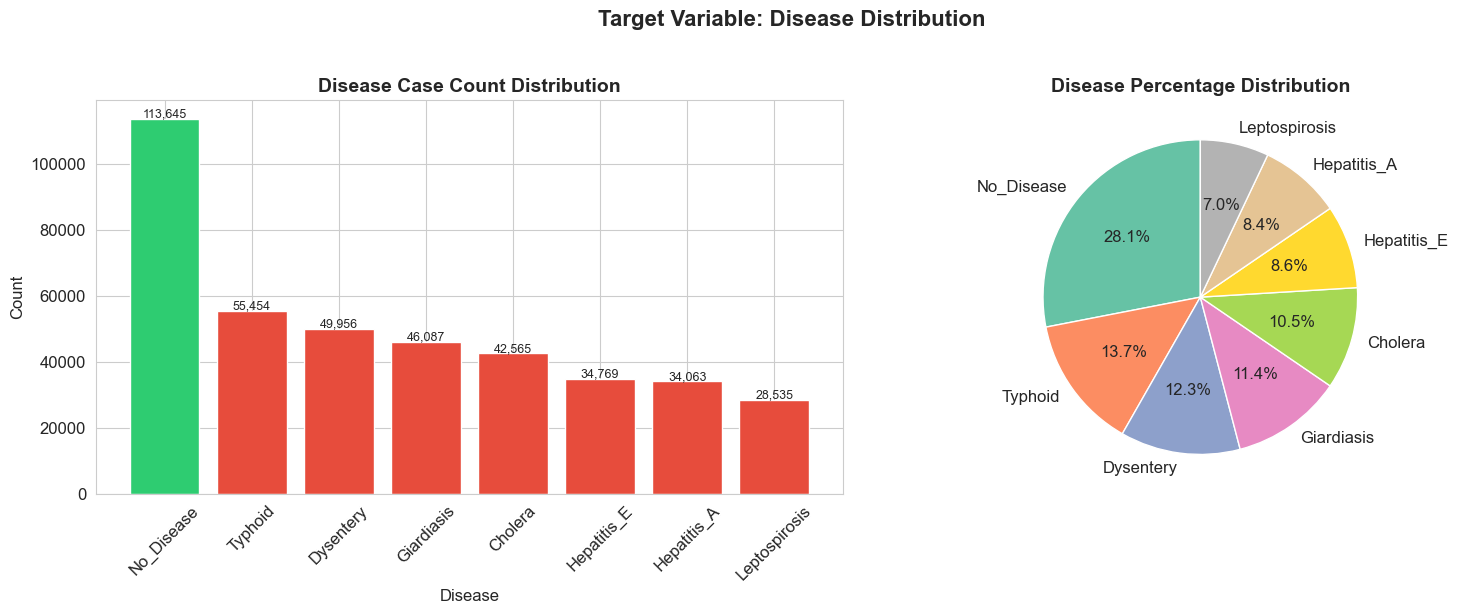

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart 
colors = ['#e74c3c' if d != 'No_Disease' else '#2ecc71' for d in disease_counts.index]
axes[0].bar(disease_counts.index, disease_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Disease Case Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

for i, (idx, val) in enumerate(disease_counts.items()):
    axes[0].text(i, val+500, f'{val:,}', ha='center', fontsize = 9)

# Pie chart
axes[1].pie(disease_counts.values, labels=disease_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(disease_counts)))
axes[1].set_title('Disease Percentage Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Disease Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- `disease` has 8 unique classes — **No_Disease dominates** with 113,645 records (28.1%), while **Leptospirosis has the least** with 28,535 records (7.0%).
- `disease` — **Typhoid is the most common disease** with 55,454 records (13.7%), followed by Dysentery (49,956) and Giardiasis (46,087).
- `disease` — **Waterborne diseases account for a significant share of cases**, with Typhoid, Dysentery, Giardiasis, and Cholera contributing nearly 48% of all records.
- `disease` — The maximum-to-minimum class ratio is **3.98x**, indicating **moderate class imbalance** but no severely underrepresented disease class.
- `disease` — Disease classes are reasonably well distributed, making the dataset suitable for **multiclass classification modeling**.

## 5. Geographic Analysis

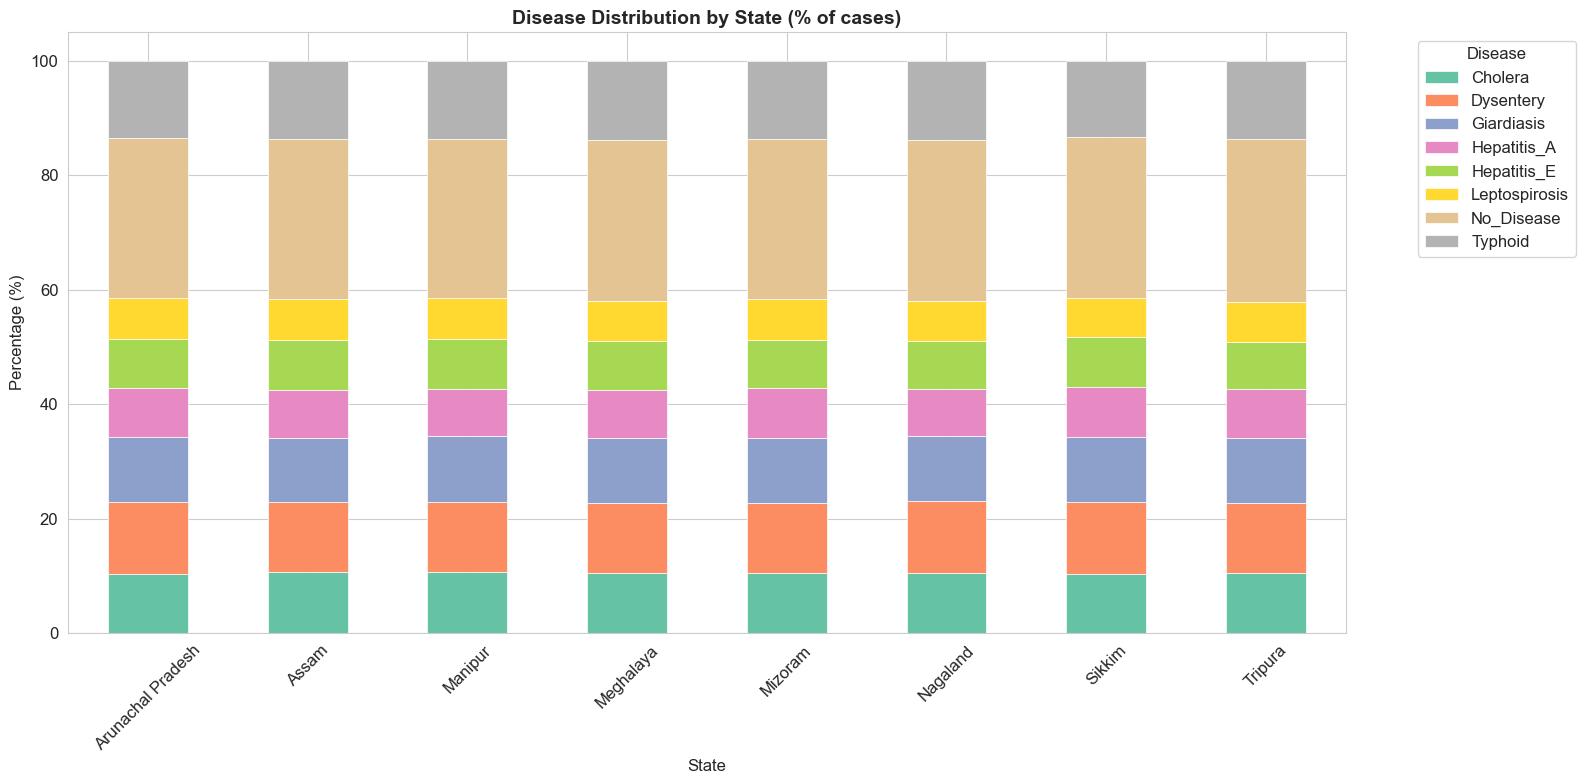

In [10]:
import os
os.makedirs('plots', exist_ok=True)

# State-wise disease distribution
state_disease = data.groupby(['state', 'disease']).size().unstack(fill_value=0)
state_disease_pct = state_disease.div(state_disease.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
state_disease_pct.plot(kind='bar', stacked=True, ax=ax,
                        colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('Disease Distribution by State (% of cases)', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Disease', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/02_state_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- Disease distribution is **almost identical across all 8 states** — every state shows the same proportional breakdown of diseases.
- This tells us **state alone is NOT a strong predictor** of disease type — the model won't learn much from the `state` column by itself.
- **No_Disease (tan/beige) dominates every state** at ~28%, confirming consistent class imbalance across geography.
- **Dysentery, Giardiasis, Hepatitis_A, Hepatitis_E, Leptospirosis, Cholera, Typhoid** all appear in roughly equal proportions across states — disease burden is uniformly distributed geographically.
- This uniformity strongly suggests that **water quality, sanitation, and climate features** (not geography) are the real drivers of disease — which is exactly what we want for a generalizable ML model.
- **Implication for modeling**: `state` and `district` can likely be **dropped** without hurting model performance — lat/lon and water quality features carry the actual signal.

=== DISEASE CASES PER STATE (excluding No_Disease) ===
state
Assam                69596
Arunachal Pradesh    44944
Nagaland             38161
Meghalaya            37960
Manipur              31272
Mizoram              27872
Tripura              27631
Sikkim               13993
Name: count, dtype: int64


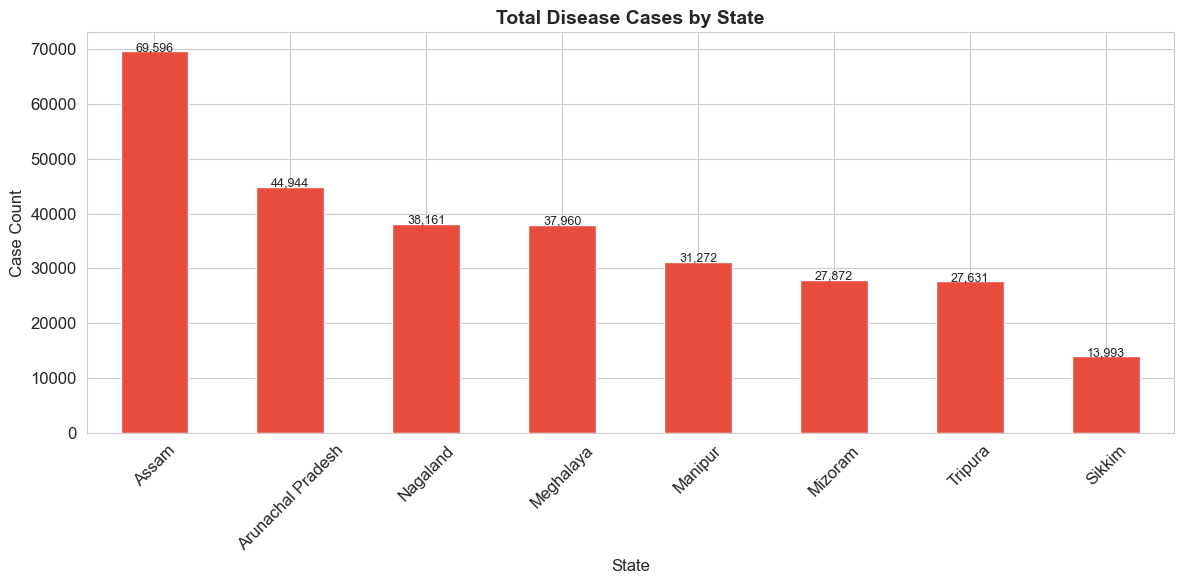

In [12]:
# Total cases per state
state_cases = data[data['disease'] != 'No_Disease']['state'].value_counts()
print('=== DISEASE CASES PER STATE (excluding No_Disease) ===')
print(state_cases)

fig, ax = plt.subplots(figsize=(12, 6))
state_cases.plot(kind='bar', color='#e74c3c', ax=ax, edgecolor='white')
ax.set_title('Total Disease Cases by State', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Case Count')
ax.tick_params(axis='x', rotation=45)
for i, val in enumerate(state_cases.values):
    ax.text(i, val + 100, f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/03_cases_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **Assam has the highest disease burden (69,596 cases)** — nearly 5x more than Sikkim and ~1.5x more than Arunachal Pradesh. Directly reflects Assam's larger population (96,559 records in dataset).
- **Sikkim has the lowest case count (13,993)** — smallest population in the dataset (19,459 records), consistent with it being India's least populous state.
- However, when compared with the previous stacked bar chart, **disease proportions are identical across states** — meaning Assam's higher raw count is purely due to population size, not higher disease risk per capita.
- **Implication**: Raw case count differences between states are population-driven, not risk-driven. This further confirms `state` is a weak predictor and should likely be **dropped** from the feature set before modeling.

In [16]:
# Geographic scatter — disease hotspots
disease_only = data[data['disease'] != 'No_Disease'].sample(n=min(10000, len(data)), random_state=42)

fig = px.scatter_mapbox(
    disease_only,
    lat='latitude', lon='longitude',
    color='disease',
    hover_data=['state', 'district', 'disease'],
    mapbox_style='open-street-map',
    zoom=5, center={'lat': 25.5, 'lon': 93.0},
    title='Disease Hotspots Across Northeast India',
    opacity=0.6,
    height=600
)
fig.show()

## 6. Seasonal & Climate Analysis

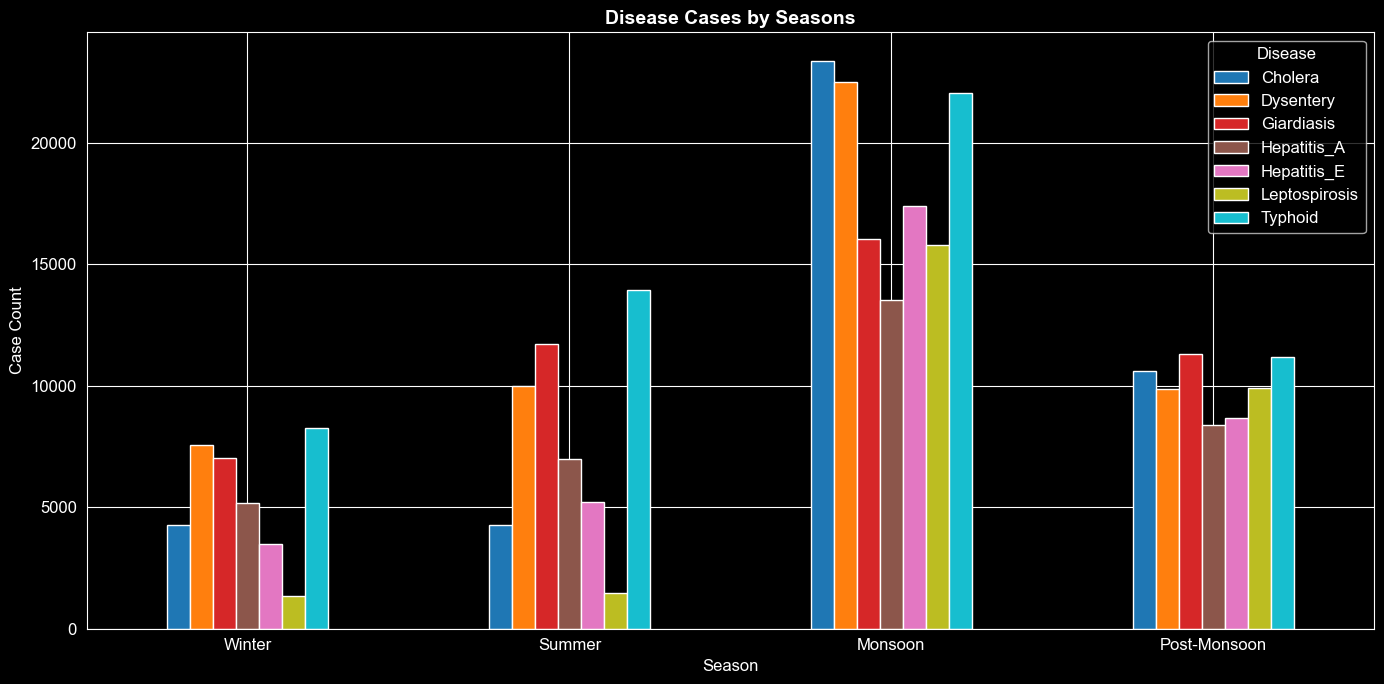

In [19]:
season_disease = data[data['disease'] != 'No_Disease'].groupby(['season', 'disease']).size().unstack(fill_value=0)
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_disease = season_disease.reindex(season_order)

fig, ax = plt.subplots(figsize=(14, 7))
season_disease.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title("Disease Cases by Seasons", fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Case Count')
ax.tick_params(axis='x', rotation = 0)
ax.legend(title='Disease')
plt.tight_layout()
plt.savefig('plots/04_disease_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **Monsoon season drives the highest burden across ALL disease types** — every disease peaks during monsoon, confirming rainfall and flooding as the primary environmental trigger.
- **Cholera and Dysentery spike most sharply in Monsoon** (23,000+ and 22,000+ cases) compared to Winter (~4,000 each) — a ~5x seasonal surge, directly linked to contaminated floodwater.
- **Typhoid is uniquely high in Summer (14,000)** compared to other diseases in the same season — suggesting heat-driven water contamination as an additional pathway beyond flooding.
- **Leptospirosis is nearly absent in Winter and Summer** but jumps in Monsoon (~16,000) — consistent with its known transmission through flood water and soil contact.
- **Hepatitis_A and Hepatitis_E remain relatively low across all seasons** compared to Cholera/Dysentery/Typhoid — suggesting fecal-oral route is less dominant than direct water contamination in this region.
- **Post-Monsoon still shows elevated cases** for all diseases — waterborne risk doesn't drop immediately after monsoon ends, contamination persists in water sources.
- **Implication for modeling**: `season` and `month` are strong predictive features — keep both, apply cyclical encoding to `month`.